# Usecase 4: EMP environment classification — original baseline

Reproduces the Random Forest baseline of [Thompson et al. 2017](https://doi.org/10.1038/nature24621) on the published EMP split: fit on the 2,000-sample subset of the Deblur 90-bp table, predict the remaining QC-filtered samples (Extended Data Fig. 5c, "Overall success rate was 84%"). The paper used the R packages `caret` and `randomForest`; the pipeline is in the EMP repository under `code/06-beta-diversity/random-forest/` and is reproduced faithfully here: `caret::nearZeroVar(freqCut = 99/1, uniqueCut = 1)`, then `caret::findCorrelation(cor(x), 0.9)` (both fitted on the training split only), then a Random Forest with `ntree = 500` and EMP's `mtry` grid `floor(seq(10, p, length = 10))`, scored by Kappa under 10-fold CV repeated 5 times and selected with caret's `oneSE` rule.

The baseline runs on both rarefaction arms produced by `n1_data.ipynb` — `data_splits_u4_rare5000` (5,000 reads per sample) and `data_splits_u4` (raw counts) — because the paper does not state which its classifier used. Both hold relative abundances; for a tree ensemble the rarefied arm's constant rescaling is immaterial, so the arms differ only in the rarefaction.

`n1_data.ipynb` drops the two EMPO-3 classes with no held-out samples, so this notebook sees 15 classes and 1,870 training samples.

Deviations from the published set-up:
1. **scikit-learn `RandomForestClassifier` instead of R `caret`/`randomForest`**, with `nodesize = 1` and bootstrap sampling. scikit-learn averages per-tree probabilities where `randomForest` takes a majority vote, and its CV folds are drawn independently of caret's.
2. **The rarefied training rows are not EMP's published `subset_2k.rare_5000` table** but the matching rows of the QC-filtered rarefied table, so train and test share one rarefaction draw. The two tables are different draws — see `n1_data.ipynb`.
3. **Splits are read from the pickles directly** rather than through `src.eval_originals.load_baseline_split`, which expects a separate feature-table TSV; u4's source is a BIOM.

Metrics follow ritme's `_calculate_classification_metrics` so the baseline is comparable to the ritme runs, with one addition: **accuracy is reported here because the paper reports it, and ritme computes no accuracy metric at all.** Every remaining class has held-out samples, so the AUROC and log-loss class sets match ritme's exactly.

This notebook can be run in the following conda environment (the last command must be launched from the root of this repository):
```shell
mamba create -n ritme_usecases -c adamova -c conda-forge -c bioconda -c pytorch ritme ipykernel nbconvert -y
conda activate ritme_usecases
pip install papermill
pip install -e .
```
The caret protocol fits 500 forests per arm (~14 h raw arm, ~2.5 h rarefied); per-`mtry` resample scores are cached under `../result_figures/_cache_u4_original/`, so a rerun resumes. Execute headless from this directory:
```shell
python -m ipykernel install --user --name ritme_usecases
sbatch --cpus-per-task=32 --mem-per-cpu=12G --time=96:00:00 --wrap \
  "papermill -k ritme_usecases n4_original_setup.ipynb n4_original_setup.ipynb"
```

## Setup

In [1]:
import json
import os
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import rankdata
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    roc_auc_score,
)
from sklearn.model_selection import RepeatedStratifiedKFold

plt.rcParams.update({"font.family": "DejaVu Sans"})
os.makedirs("../result_figures", exist_ok=True)

In [2]:
######## USER INPUTS ########
# arm name -> split directory written by n1_data.ipynb
arms = {"rare5000": "data_splits_u4_rare5000", "raw": "data_splits_u4"}
# arm quoted against the published 84%, written to the unsuffixed CSV
primary_arm = "rare5000"
target = "empo_3"
# metadata columns that n1_data.ipynb places before the feature columns
metadata_columns = ["empo_3", "empo_2", "study_id", "split"]
# split shape n1_data.ipynb produces, after dropping classes without test samples
expected_n = {"train": 1870, "test": 21828}
expected_n_classes = 15
# EMP's ml_util.R uses ntree = 500 for the classification random forest
n_estimators = 500
# caret::findCorrelation cutoff from EMP's classification.R
corr_cutoff = 0.9
seed = 12
n_jobs = -1
# rows scored per chunk; the full test matrix is ~50 GiB in float64
predict_chunk = 2000
n_bootstrap = 1000
published_accuracy = 0.84
cache_dir = "../result_figures/_cache_u4_original"
######## END USER INPUTS #####

## Helpers

Multi-class analogues of `src.eval_originals.get_metrics_n_roc_curve` and
`src.bootstrap_metrics.bootstrap_classification_metrics`, which are binary-only.

In [3]:
def load_features(frame, dtype=np.float32):
    """Return the feature block of a split frame as a dense array.

    Validates the layout by name: a stale ``metadata_columns`` would otherwise
    silently shift the slice and drop real features.
    """
    head = list(frame.columns[: len(metadata_columns)])
    if head != metadata_columns:
        raise ValueError(f"unexpected metadata columns: {head}")
    features = frame.columns[len(metadata_columns) :]
    if not features.str.startswith("F").all():
        raise ValueError(
            f"non-feature columns in the feature block: {list(features[:5])}"
        )
    return frame.iloc[:, len(metadata_columns) :].to_numpy(dtype=dtype)


def predict_proba_chunked(model, frame, mask=None, chunk=predict_chunk):
    """Predict class probabilities in row chunks.

    The frame is already dense in memory; chunking avoids the additional
    whole-frame copy that a single ``load_features`` call would make. ``mask``
    selects the feature columns the caret filters kept.
    """
    out = np.empty((len(frame), len(model.classes_)), dtype=np.float64)
    for start in range(0, len(frame), chunk):
        stop = min(start + chunk, len(frame))
        block = load_features(frame.iloc[start:stop])
        if mask is not None:
            block = np.ascontiguousarray(block[:, mask])
        out[start:stop] = model.predict_proba(block)
    return out


def classes_present(y_true, classes):
    """Entries of ``classes`` that occur in ``y_true``, in ``classes`` order."""
    seen = set(np.asarray(y_true).tolist())
    return np.array([c for c in classes if c in seen])


def multiclass_metrics(y_true, y_proba, classes, split, present=None):
    """Accuracy, macro-F1, macro-OvR AUROC, log loss, balanced accuracy and MCC.

    ``present`` fixes the class set the threshold-free metrics are computed over.
    Pass the class set of the full test split so that every bootstrap resample
    estimates the same quantity; a resample that loses one of those classes then
    yields ``nan`` for AUROC and is dropped by the caller rather than silently
    averaging over fewer classes. With ``present`` covering every class (the
    case here, since ``n1_data.ipynb`` removes classes without test samples) the
    renormalisation below is a no-op and the metrics match ritme's exactly.
    """
    classes = np.asarray(classes)
    y_pred = classes[y_proba.argmax(axis=1)]
    if present is None:
        present = classes_present(y_true, classes)
    keep = np.isin(classes, present)
    proba_present = y_proba[:, keep]
    mass = proba_present.sum(axis=1, keepdims=True)
    degenerate = int((mass <= 0).sum())
    proba_present = proba_present / np.where(mass > 0, mass, 1.0)
    with warnings.catch_warnings():
        # a class of `present` missing from this y_true makes its OvR AUROC nan
        warnings.simplefilter("ignore", UserWarning)
        auc = roc_auc_score(
            y_true, proba_present, multi_class="ovr", average="macro", labels=present
        )
        f1m = f1_score(y_true, y_pred, average="macro", zero_division=0)
    return {
        f"accuracy_{split}": accuracy_score(y_true, y_pred),
        f"f1_macro_{split}": f1m,
        f"roc_auc_macro_ovr_{split}": auc,
        f"log_loss_{split}": log_loss(y_true, proba_present, labels=present),
        f"balanced_accuracy_{split}": balanced_accuracy_score(y_true, y_pred),
        f"mcc_{split}": matthews_corrcoef(y_true, y_pred),
        f"n_classes_{split}": len(present),
        f"n_rows_mass_on_absent_classes_{split}": degenerate,
    }


def bootstrap_multiclass_metrics(
    y_true, y_proba, classes, n_resamples=None, ci=0.95, seed=seed
):
    """Percentile bootstrap CIs over the held-out rows.

    Column schema matches ``src.bootstrap_metrics``: ``metric, point, mean,
    ci_low, ci_high, n_resamples, ci_pct``. The class set is frozen to that of
    the full test split, so every resample estimates the same quantity;
    resamples that lose one of those classes yield ``nan`` for AUROC and are
    excluded, which is why ``n_resamples`` for AUROC comes in below the request.
    Inspect that column before quoting the interval.

    The same ``seed`` is used for every arm, so arms are bootstrapped on
    identical resamples and their intervals are paired, not independent.
    """
    n_resamples = n_bootstrap if n_resamples is None else n_resamples
    y_true = np.asarray(y_true)
    present = classes_present(y_true, classes)
    point = multiclass_metrics(y_true, y_proba, classes, "test", present=present)
    names = [
        "accuracy_test",
        "f1_macro_test",
        "roc_auc_macro_ovr_test",
        "log_loss_test",
        "balanced_accuracy_test",
        "mcc_test",
    ]
    samples = {name: [] for name in names}
    rng = np.random.default_rng(seed)
    n = len(y_true)
    for _ in range(n_resamples):
        idx = rng.integers(0, n, size=n)
        row = multiclass_metrics(
            y_true[idx], y_proba[idx], classes, "test", present=present
        )
        for name in names:
            samples[name].append(row[name])

    alpha = (1.0 - ci) / 2.0
    rows = []
    for name in names:
        arr = np.asarray(samples[name], dtype=float)
        arr = arr[np.isfinite(arr)]
        rows.append(
            {
                "metric": name,
                "point": point[name],
                "mean": float(arr.mean()) if arr.size else float("nan"),
                "ci_low": float(np.quantile(arr, alpha)) if arr.size else float("nan"),
                "ci_high": (
                    float(np.quantile(arr, 1 - alpha)) if arr.size else float("nan")
                ),
                "n_resamples": int(arr.size),
                "ci_pct": ci,
            }
        )
    return pd.DataFrame(rows)

## EMP-faithful protocol

Ports the steps of EMP's `code/06-beta-diversity/random-forest/` R pipeline that the full-width
protocol skips: `caret::nearZeroVar(freqCut = 99/1, uniqueCut = 1)`, then
`caret::findCorrelation(cor(x), 0.9)` with caret's `exact = FALSE` rule, then
`caret::train(method = "rf", ntree = 500, tuneGrid = floor(seq(10, p, length = 10)),
metric = "Kappa", trControl = trainControl(method = "repeatedcv", number = 10, repeats = 5,
selectionFunction = "oneSE"))`.

Both filters are fitted on the training split only and applied to the held-out split. Per-`mtry`
resample scores are cached under `../result_figures/_cache_u4_original/`, so a run that is
interrupted resumes instead of repeating the 500 fits.

In [4]:
def near_zero_var(X, freq_cut=99.0, unique_cut=1.0, chunk=2000):
    """``caret::nearZeroVar``: boolean mask of columns to drop.

    A column goes when its frequency ratio (count of the most common value over
    the count of the second most common) exceeds ``freq_cut`` *and* its
    percentage of distinct values is at most ``unique_cut``. Zero-variance
    columns always go.
    """
    n, p = X.shape
    drop = np.zeros(p, dtype=bool)
    for start in range(0, p, chunk):
        block = np.asarray(X[:, start : start + chunk])
        for j in range(block.shape[1]):
            counts = np.unique(block[:, j], return_counts=True)[1]
            if counts.size == 1:
                drop[start + j] = True
                continue
            counts = np.sort(counts)[::-1]
            freq_ratio = counts[0] / counts[1]
            pct_unique = 100.0 * counts.size / n
            drop[start + j] = freq_ratio > freq_cut and pct_unique <= unique_cut
    return drop


def find_correlation(corr, cutoff=0.9):
    """``caret::findCorrelation`` with ``exact = FALSE``: indices of columns to drop.

    For every pair correlated above ``cutoff``, drops whichever column has the
    larger mean absolute correlation; caret compares the ranks of those means,
    so ties resolve the same way (``rankdata(..., method="dense")``). The mean
    is taken over the full column including the diagonal, as ``colMeans(abs(x))``
    does.

    caret's default is ``exact = ncol(x) < 100``, and only the ``exact = FALSE``
    branch is reproduced here, so a narrow matrix is refused rather than scored
    by the wrong rule.
    """
    corr = np.asarray(corr)
    if corr.shape[0] < 100:
        raise ValueError(
            f"caret would use its exact branch at {corr.shape[0]} columns; "
            f"only the exact=FALSE branch is implemented."
        )
    if not np.isfinite(corr).all():
        raise ValueError(
            f"{int((~np.isfinite(corr)).sum())} non-finite correlations; caret's "
            f"cor() would return NA here. Remove constant columns first."
        )
    rank = rankdata(np.abs(corr).mean(axis=0), method="dense")
    mask = np.abs(corr) > cutoff
    np.fill_diagonal(mask, False)
    rows, cols = np.nonzero(mask)
    upper = rows < cols
    rows, cols = rows[upper], cols[upper]
    discard_col = rank[cols] > rank[rows]
    return np.unique(np.concatenate([cols[discard_col], rows[~discard_col]]))


def one_se_choice(mean_metric, sd_metric, n_resamples):
    """``caret``'s ``oneSE`` rule: the simplest model within one standard error of the best.

    The grid is ordered by ascending ``mtry``, which is caret's complexity
    ordering for a random forest, so "simplest" is the smallest surviving index.
    """
    best = int(np.argmax(mean_metric))
    se = sd_metric[best] / np.sqrt(n_resamples)
    threshold = mean_metric[best] - se
    return int(min(i for i, m in enumerate(mean_metric) if m >= threshold))


def emp_caret_filters(X_train):
    """Apply EMP's two filters, fitted on the training split. Returns (mask, report).

    Both run in float64: ``nearZeroVar`` counts distinct values, and a float32
    input can merge values that R would have counted separately.
    """
    X64 = np.asarray(X_train, dtype=np.float64)
    nzv = near_zero_var(X64)
    kept = np.flatnonzero(~nzv)
    corr = np.corrcoef(X64[:, kept], rowvar=False)
    del X64
    too_high = find_correlation(corr, cutoff=corr_cutoff)
    del corr
    mask = np.zeros(X_train.shape[1], dtype=bool)
    mask[np.delete(kept, too_high)] = True
    return mask, {
        "n_features_in": int(X_train.shape[1]),
        "n_removed_near_zero_var": int(nzv.sum()),
        "n_removed_correlated": int(len(too_high)),
        "n_features_out": int(mask.sum()),
    }


def emp_caret_grid(n_features):
    """EMP's ``mtry`` grid: ``floor(seq(10, p, length = 10))``."""
    return [int(v) for v in np.floor(np.linspace(10, n_features, 10))]


def emp_caret_tune(X, y, arm, cache_dir):
    """Score EMP's ``mtry`` grid by Kappa under 10-fold CV repeated 5 times.

    One JSON per ``mtry`` under ``cache_dir``, so an interrupted run resumes.
    Returns the per-``mtry`` mean and SD of Kappa across the 50 resamples.
    """
    grid = emp_caret_grid(X.shape[1])
    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=seed)
    folds = list(cv.split(X, y))
    os.makedirs(cache_dir, exist_ok=True)
    scores = {}
    for mtry in grid:
        cache = os.path.join(cache_dir, f"{arm}_mtry{mtry}.json")
        if os.path.exists(cache):
            with open(cache) as f:
                scores[mtry] = json.load(f)
            print(
                f"  [cached] mtry={mtry}: Kappa {np.mean(scores[mtry]):.4f}", flush=True
            )
            continue
        started = time.perf_counter()
        kappas = []
        for train_idx, val_idx in folds:
            fold_model = RandomForestClassifier(
                n_estimators=n_estimators,
                max_features=mtry,
                random_state=seed,
                n_jobs=n_jobs,
            ).fit(X[train_idx], y[train_idx])
            kappas.append(
                float(cohen_kappa_score(y[val_idx], fold_model.predict(X[val_idx])))
            )
        with open(cache, "w") as f:
            json.dump(kappas, f)
        scores[mtry] = kappas
        print(
            f"  mtry={mtry}: Kappa {np.mean(kappas):.4f} +/- {np.std(kappas, ddof=1):.4f}"
            f" ({time.perf_counter() - started:.0f} s)",
            flush=True,
        )
    means = [float(np.mean(scores[m])) for m in grid]
    sds = [float(np.std(scores[m], ddof=1)) for m in grid]
    return grid, means, sds, len(folds)

## Train and evaluate both rarefaction arms

For each arm: apply EMP's filters (fitted on train), tune `mtry` under the caret protocol,
refit at the `oneSE` choice, then score the 21,828 held-out samples in chunks.

In [5]:
results, bootstraps, per_class, confusions, tuning = {}, {}, {}, {}, {}

for arm, splits_dir in arms.items():
    key = f"emp_caret_{arm}"
    print(f"===== {key} ({splits_dir})", flush=True)
    train = pd.read_pickle(os.path.join(splits_dir, "train_val.pkl"))
    if train.shape[0] != expected_n["train"]:
        raise ValueError(f"{key}: {train.shape[0]} training rows")
    X_train, y_train = load_features(train), train[target].to_numpy()
    if len(np.unique(y_train)) != expected_n_classes:
        raise ValueError(f"{key}: {len(np.unique(y_train))} classes")

    mask, filter_report = emp_caret_filters(X_train)
    X_train = np.ascontiguousarray(X_train[:, mask])
    print(f"  filters: {json.dumps(filter_report)}", flush=True)
    grid, means, sds, n_resamples = emp_caret_tune(X_train, y_train, arm, cache_dir)
    chosen = grid[one_se_choice(means, sds, n_resamples)]
    tuning[key] = {
        **filter_report,
        "mtry_grid": grid,
        "kappa_mean": means,
        "kappa_sd": sds,
        "n_resamples": n_resamples,
        "best_mtry_by_kappa": grid[int(np.argmax(means))],
        "mtry_selected_one_se": chosen,
    }
    print(
        f"  oneSE picked mtry={chosen} (best Kappa at {tuning[key]['best_mtry_by_kappa']})"
    )

    model = RandomForestClassifier(
        n_estimators=n_estimators, max_features=chosen, random_state=seed, n_jobs=n_jobs
    ).fit(X_train, y_train)
    classes = model.classes_
    metrics = multiclass_metrics(
        y_train, predict_proba_chunked(model, train, mask=mask), classes, "train"
    )
    del train, X_train

    test = pd.read_pickle(os.path.join(splits_dir, "test.pkl"))
    if test.shape[0] != expected_n["test"]:
        raise ValueError(f"{key}: {test.shape[0]} test rows")
    y_test = test[target].to_numpy()
    proba_test = predict_proba_chunked(model, test, mask=mask)
    del test
    metrics.update(multiclass_metrics(y_test, proba_test, classes, "test"))
    results[key] = metrics

    y_pred = classes[proba_test.argmax(axis=1)]
    per_class[key] = pd.DataFrame(
        classification_report(y_test, y_pred, zero_division=0, output_dict=True)
    ).T
    confusions[key] = pd.DataFrame(
        confusion_matrix(y_test, y_pred, labels=classes, normalize="true"),
        index=classes,
        columns=classes,
    )
    bootstraps[key] = bootstrap_multiclass_metrics(y_test, proba_test, classes)
    print(
        f"  test accuracy {metrics['accuracy_test']:.4f}"
        f" | macro-F1 {metrics['f1_macro_test']:.4f}",
        flush=True,
    )
    del model, proba_test

metrics_df = pd.DataFrame(results).T.astype(float)
metrics_df

===== emp_caret_rare5000 (data_splits_u4_rare5000)


  filters: {"n_features_in": 303200, "n_removed_near_zero_var": 299574, "n_removed_correlated": 88, "n_features_out": 3538}


  [cached] mtry=10: Kappa 0.8679


  [cached] mtry=402: Kappa 0.8666


  [cached] mtry=794: Kappa 0.8640


...

/cluster/project/bokulich/adamova/_conda_envs/ritme_usecases/lib/python3.14/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


/cluster/project/bokulich/adamova/_conda_envs/ritme_usecases/lib/python3.14/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


/cluster/project/bokulich/adamova/_conda_envs/ritme_usecases/lib/python3.14/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  test accuracy 0.8532 | macro-F1 0.7509


,accuracy_train,f1_macro_train,roc_auc_macro_ovr_train,log_loss_train,balanced_accuracy_train,mcc_train,n_classes_train,n_rows_mass_on_absent_classes_train,accuracy_test,f1_macro_test,roc_auc_macro_ovr_test,log_loss_test,balanced_accuracy_test,mcc_test,n_classes_test,n_rows_mass_on_absent_classes_test
emp_caret_rare5000,1.000000,1.000000,1.0,0.156920,1.000000,1.000000,15.0,0.0,0.838235,0.747810,0.959409,0.739126,0.846274,0.814802,15.0,0.0
emp_caret_raw,0.999465,0.999481,1.0,0.120257,0.999479,0.999427,15.0,0.0,0.853216,0.750925,0.973518,0.571888,0.823001,0.830335,15.0,0.0


## Comparison with the published result

In [6]:
comparison = metrics_df[
    ["accuracy_test", "f1_macro_test", "roc_auc_macro_ovr_test"]
].copy()
comparison["published_accuracy"] = published_accuracy
comparison["accuracy_difference"] = comparison["accuracy_test"] - published_accuracy
comparison

,accuracy_test,f1_macro_test,roc_auc_macro_ovr_test,published_accuracy,accuracy_difference
emp_caret_rare5000,0.838235,0.747810,0.959409,0.84,-0.001765
emp_caret_raw,0.853216,0.750925,0.973518,0.84,0.013216


Per-class scores on the held-out set — the thin classes are the ones to read.

In [7]:
per_class[f"emp_caret_{primary_arm}"].round(3)

,precision,recall,f1-score,support
Aerosol (non-saline),0.300,0.750,0.429,4.000
Animal corpus,0.884,0.990,0.934,200.000
Animal distal gut,0.922,0.852,0.886,4030.000
Animal proximal gut,0.864,0.983,0.920,239.000
Animal secretion,0.693,0.696,0.695,1144.000
Animal surface,0.688,0.884,0.774,2818.000
Plant corpus,0.004,0.500,0.008,2.000
Plant rhizosphere,0.525,0.998,0.688,426.000
Plant surface,0.975,0.996,0.985,1483.000
Sediment (non-saline),0.478,0.988,0.644,416.000


## Bootstrap 95% CIs on test metrics

Resamples the 21,828 held-out rows 1000 times on a class set frozen to the full test split. The primary (rarefied) arm is written to `../result_figures/bootstrap_test_metrics_u4_original.csv` for `evaluate_all_trials.ipynb`; the raw arm is written beside it.

In [8]:
primary_key = f"emp_caret_{primary_arm}"
for key, boot in bootstraps.items():
    suffix = "" if key == primary_key else f"_{key}"
    boot.to_csv(
        f"../result_figures/bootstrap_test_metrics_u4_original{suffix}.csv", index=False
    )
    print(f"----- {key}")
    print(boot.to_string(index=False))

----- emp_caret_rare5000
                metric    point     mean   ci_low  ci_high  n_resamples  ci_pct
         accuracy_test 0.838235 0.838292 0.833331 0.843367         1000    0.95
         f1_macro_test 0.747810 0.746213 0.719284 0.768293         1000    0.95
roc_auc_macro_ovr_test 0.959409 0.958547 0.927623 0.991141          840    0.95
         log_loss_test 0.739126 0.738851 0.727968 0.749254         1000    0.95
balanced_accuracy_test 0.846274 0.849666 0.793842 0.896728         1000    0.95
              mcc_test 0.814802 0.814873 0.809315 0.820549         1000    0.95
----- emp_caret_raw
                metric    point     mean   ci_low  ci_high  n_resamples  ci_pct
         accuracy_test 0.853216 0.853261 0.848406 0.858118         1000    0.95
         f1_macro_test 0.750925 0.750289 0.737365 0.764311         1000    0.95
roc_auc_macro_ovr_test 0.973518 0.973015 0.954645 0.992251          840    0.95
         log_loss_test 0.571888 0.571680 0.561727 0.581590         1000    

## Confusion matrices

Row-normalised over true classes, the orientation of EMP's published `data/random-forest/empo_3_cm.txt`.

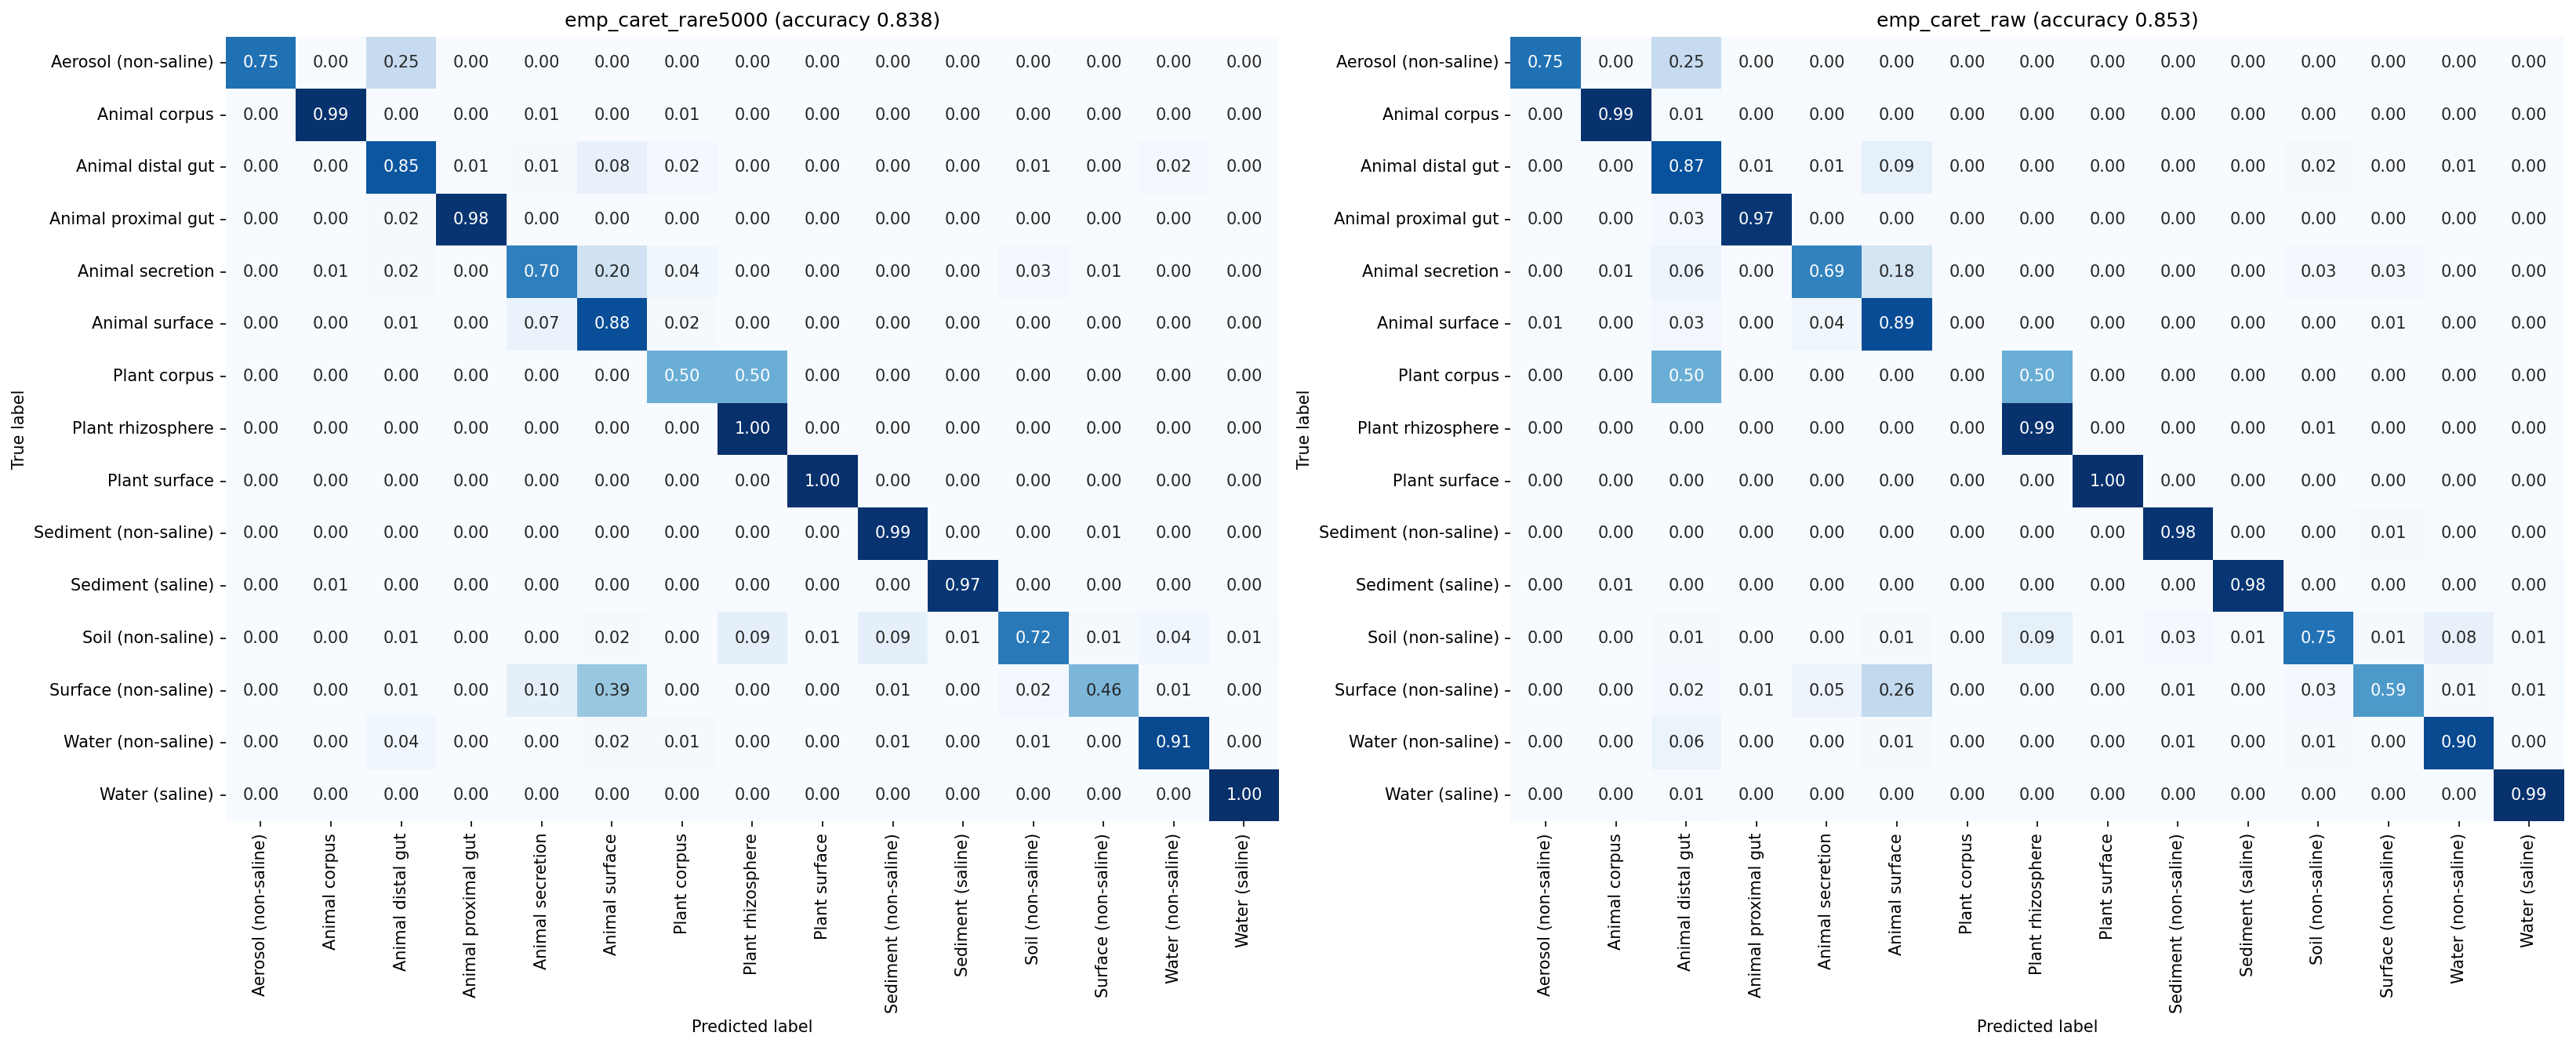

In [9]:
keys = list(confusions)
fig, axs = plt.subplots(1, len(keys), figsize=(11 * len(keys), 9), dpi=150)
for ax, key in zip(np.atleast_1d(axs), keys):
    sns.heatmap(
        confusions[key],
        cmap="Blues",
        annot=True,
        fmt=".2f",
        vmin=0,
        vmax=1,
        ax=ax,
        cbar=False,
    )
    ax.set_title(f"{key} (accuracy {results[key]['accuracy_test']:.3f})")
    ax.set_ylabel("True label")
    ax.set_xlabel("Predicted label")
fig.tight_layout()
fig.savefig(
    "../result_figures/confusion_matrix_u4_original.pdf", bbox_inches="tight", dpi=400
)

## Save metrics

In [10]:
metrics_df.to_csv("../result_figures/u4_original_metrics.csv")
for key in results:
    confusions[key].to_csv(f"../result_figures/confusion_matrix_u4_original_{key}.csv")
    per_class[key].to_csv(f"../result_figures/per_class_u4_original_{key}.csv")
with open("../result_figures/u4_original_tuning.json", "w") as f:
    json.dump(tuning, f, indent=2)
metrics_df.round(4)

,accuracy_train,f1_macro_train,roc_auc_macro_ovr_train,log_loss_train,balanced_accuracy_train,mcc_train,n_classes_train,n_rows_mass_on_absent_classes_train,accuracy_test,f1_macro_test,roc_auc_macro_ovr_test,log_loss_test,balanced_accuracy_test,mcc_test,n_classes_test,n_rows_mass_on_absent_classes_test
emp_caret_rare5000,1.0000,1.0000,1.0,0.1569,1.0000,1.0000,15.0,0.0,0.8382,0.7478,0.9594,0.7391,0.8463,0.8148,15.0,0.0
emp_caret_raw,0.9995,0.9995,1.0,0.1203,0.9995,0.9994,15.0,0.0,0.8532,0.7509,0.9735,0.5719,0.8230,0.8303,15.0,0.0


## Sanity checks

In [11]:
assert __debug__, "run without python -O so these checks execute"

for key, m in results.items():
    assert m["n_classes_test"] == expected_n_classes, (key, m["n_classes_test"])
    assert m["n_rows_mass_on_absent_classes_test"] == 0, key
    assert 0.0 <= m["accuracy_test"] <= 1.0 and np.isfinite(m["roc_auc_macro_ovr_test"])
    boot = bootstraps[key].set_index("metric")
    # the point estimate must sit inside its own interval
    for metric, row in boot.iterrows():
        assert row["ci_low"] <= row["point"] <= row["ci_high"], (key, metric, dict(row))
    # AUROC drops resamples that lose a class; the other metrics use all of them
    assert boot.loc["accuracy_test", "n_resamples"] == n_bootstrap
    assert boot.loc["roc_auc_macro_ovr_test", "n_resamples"] <= n_bootstrap
    print(
        key,
        "usable AUROC resamples:",
        int(boot.loc["roc_auc_macro_ovr_test", "n_resamples"]),
    )

for key, info in tuning.items():
    # EMP's filters must actually have removed features, and oneSE must pick
    # a value on the grid under the full 10-fold x 5-repeat protocol
    assert info["n_features_out"] < info["n_features_in"], key
    assert info["mtry_selected_one_se"] in info["mtry_grid"], key
    assert info["n_resamples"] == 50, (key, info["n_resamples"])
print("All sanity checks passed.")

emp_caret_rare5000 usable AUROC resamples: 840
emp_caret_raw usable AUROC resamples: 840
All sanity checks passed.
